<a href="https://colab.research.google.com/github/Emmanuel-Favour/Intro-to-Machine-Learning/blob/main/Spam_Filter_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spam Email Detection
# Naive Bayes Models & KNN
* About the project: The dataset of about 5574 rows and 2 columns being used in the project was forked from a github repository. The dataset consist of spam dataset and the project involves the use of supervised machine learning model (Naive Bayes  Models i.e (GausianNB, BernouliNB, MultinomialNB) and KNN Model).
* The above task is to be carried out using  classification Models, which helps to predict incoming emails on a device to be either Spam or not.


#### Loading libraries

In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

#### Data Gathering

In [2]:
#loading dataset
email_df = pd.read_csv("spam.csv", encoding='latin1')

In [3]:
email_df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ã¼ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


#### Data Assessment

In [4]:
#using the describe funtion to get statistical summary of the dataset.
email_df.describe()

,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


In [5]:
#using the describe function to get statistical summary of the category column of the dataset.
email_df.groupby("Category").describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

In [6]:
#Using the info() function to the an overview of the dataset.
email_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [7]:
#Using the isnull and sum function to get the sum of all null values.
email_df.isnull().sum().sum()

np.int64(0)

In [8]:
#Using the loc function to slice the dataset for index of the null values.
display(email_df.loc[(email_df["Message"].isnull() )])

,Category,Message


In [9]:
#getting a list of the null value index with the
email_df[email_df["Message"].isnull()].index.tolist()

[]

#### Data cleaning

In [10]:
#Replacing null values with random email texts.
email_df.loc[5082, "Message"] = "Please find attached to this email the copies of the document you requested for"
email_df.loc[5083, 'Message'] = "This is to let you know that PTCCentre is going live on Mixlr right now. Listen live now."

In [11]:
#Confirming if the list of null has been replaced.
email_df[email_df["Message"].isnull()].index.tolist()

[]

In [12]:
#Creating a new column
email_df["variable"] = email_df["Category"].apply(lambda x: 1 if x=="spam" else 0)
email_df

,Category,Message,variable
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1
5568,ham,Will Ã¼ b going to esplanade fr home?,0
5569,ham,"Pity, * was in mood for that. So...any other s...",0
5570,ham,The guy did some bitching but I acted like i'd...,0


In [13]:
cv = CountVectorizer()
print(email_df.Message)
email_df_count = cv.fit_transform(email_df.Message)
email_df_count.toarray()

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ã¼ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: str


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5572, 8741))

In [14]:
#Create train/split function
x_train, x_test, y_train, y_test = train_test_split(email_df_count, email_df.variable, test_size = 0.25)

In [15]:
#training the multinomial model
multi = MultinomialNB()
multi.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [16]:
#training the bernoulli model
BernNB = BernoulliNB()
BernNB.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [17]:
#training the Gaussian model
Gauss= GaussianNB()
x_train_dense = x_train.toarray()
Gauss.fit(x_train_dense, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [18]:
#Training the KNN Model
KNN = KNeighborsClassifier(n_neighbors=101)
KNN.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",101
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Evaluating Model Performance.
* Accuracy Test

In [19]:
#Testing Multinomial model Accuracy
pred1 = multi.predict(x_test)
print(accuracy_score(pred1, y_test, normalize=True))

0.9820531227566404


In [20]:
#Testing Bernouli model Accuracy
pred2 = BernNB.predict(x_test)
print(accuracy_score(pred2, y_test, normalize=True))

0.9820531227566404


In [21]:
#Testing KNN model Accuracy
pred3 = KNN.predict(x_test)
print(accuracy_score(pred3, y_test, normalize=True))

0.8528356066044508


In [22]:
#Getting the test and train accuracy values for neighbor range 1-25
train_accuracies = {}
test_accuracies = {}
neighbors = np.arange(1,26)
for neighbor in neighbors:
    Knn = KNeighborsClassifier(n_neighbors = neighbor)
    prd = Knn.fit(x_train, y_train)
    train_accuracies[neighbor] = Knn.score(x_train, y_train)
    test_accuracies[neighbor] = Knn.score(x_test, y_test)



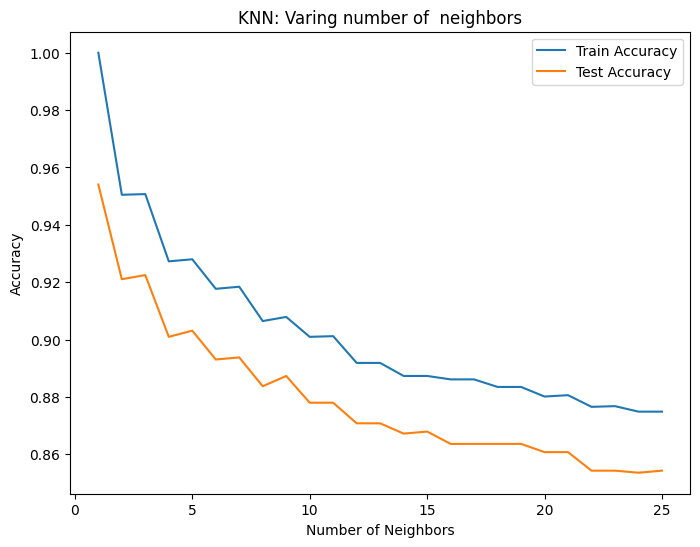

In [23]:
#Ploting the training and text accuracy values for neighbor range 1-25
plt.figure(figsize=(8,6))
plt.title("KNN: Varing number of  neighbors")
plt.plot(neighbors, train_accuracies.values(), label="Train Accuracy")
plt.plot(neighbors, test_accuracies.values(), label="Test Accuracy")
plt.legend()
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.show()

In [24]:
#Testing GaussianNB model Accuracy
x_test_dense = x_test.toarray()
pred4 = Gauss.predict(x_test_dense)
print(accuracy_score(pred4, y_test, normalize=True))


0.9138549892318737


#### Summary
* From the Model Performance by accuracy, the Multinomial model predicted better with an accuracy of 0.98 and very close to it was Bernoulli with a prediction accuracy 0.97 score
* KNN and GaussianNB were a bit far from the mark even after a bit of hyper-parameter tuning with the KNN models, it appears that the it highest accuracy at a n_neighbor = 1 is still not good enough.

In [25]:
mess = [""]

# Vectorize message
mess_vec = cv.transform(mess)

# Predict
prediction = multi.predict(mess_vec)

print(prediction)

[0]
